<a href="https://colab.research.google.com/github/NishanRegmi/Deep-Learning/blob/main/Early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions
import warnings

In [26]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=41)

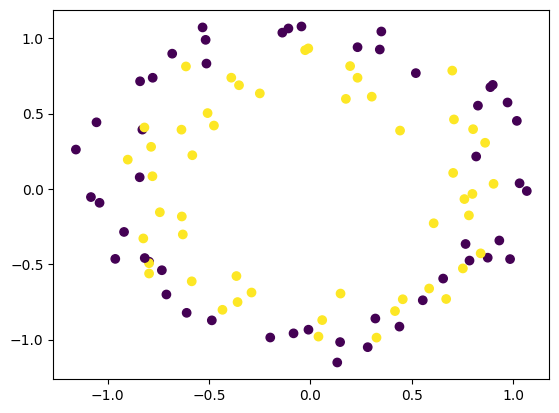

In [27]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

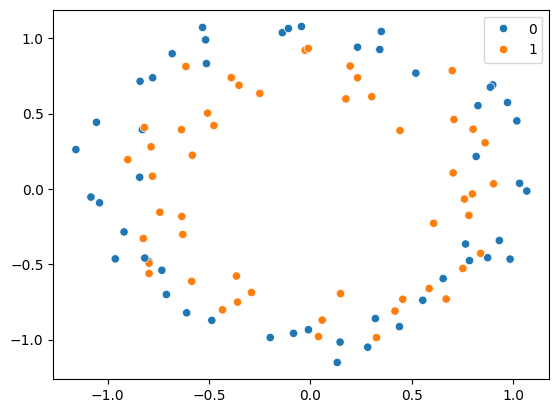

In [28]:
#using seaborn
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [30]:
model = Sequential()

In [31]:
model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [33]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1500)

Epoch 1/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - accuracy: 0.4750 - loss: 0.6951 - val_accuracy: 0.4500 - val_loss: 0.7040
Epoch 2/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5000 - loss: 0.6916 - val_accuracy: 0.3000 - val_loss: 0.7093
Epoch 3/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6905 - val_accuracy: 0.3000 - val_loss: 0.7123
Epoch 4/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6901 - val_accuracy: 0.3000 - val_loss: 0.7155
Epoch 5/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5625 - loss: 0.6895 - val_accuracy: 0.3000 - val_loss: 0.7183
Epoch 6/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5750 - loss: 0.6884 - val_accuracy: 0.3000 - val_loss: 0.7196
Epoch 7/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5750 - loss: 0.6879 - val_accuracy: 0.3000 - val_loss: 0.7224
Epoch 8/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5750 - loss: 0.6871 - val_accuracy: 0.3000 - 

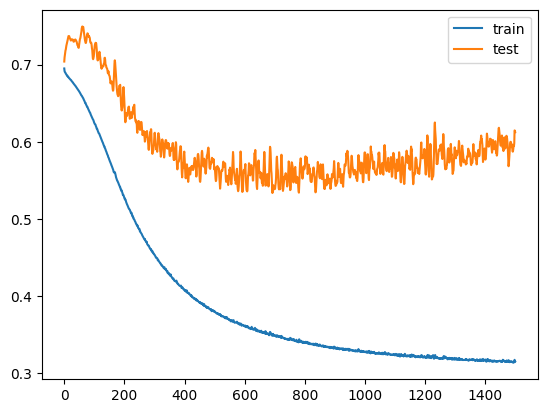

In [34]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

From above graph, it is clear that there is clear overfitting.

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


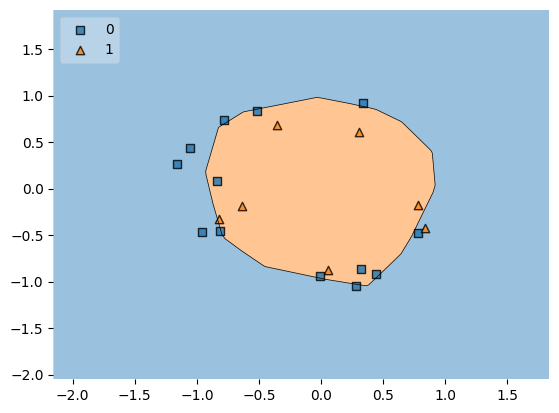

In [35]:
plot_decision_regions(X_test, y_test.ravel(), clf= model, legend=2)
plt.show()

**Early Stopping**

In [36]:
model = Sequential()

In [37]:
model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

In [38]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [39]:
callback = EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0.00001,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
    )

In [40]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1500, callbacks=callback)

Epoch 1/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - accuracy: 0.4750 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6838
Epoch 2/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6935 - val_accuracy: 0.4500 - val_loss: 0.6892
Epoch 3/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6924 - val_accuracy: 0.4500 - val_loss: 0.6944
Epoch 4/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5125 - loss: 0.6910 - val_accuracy: 0.4500 - val_loss: 0.6986
Epoch 5/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5375 - loss: 0.6896 - val_accuracy: 0.4500 - val_loss: 0.7024
Epoch 6/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5500 - loss: 0.6894 - val_accuracy: 0.4500 - val_loss: 0.7058
Epoch 7/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5500 - loss: 0.6881 - val_accuracy: 0.4500 - val_loss: 0.7069
Epoch 8/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5500 - loss: 0.6872 - val_accuracy: 0.4500 - 

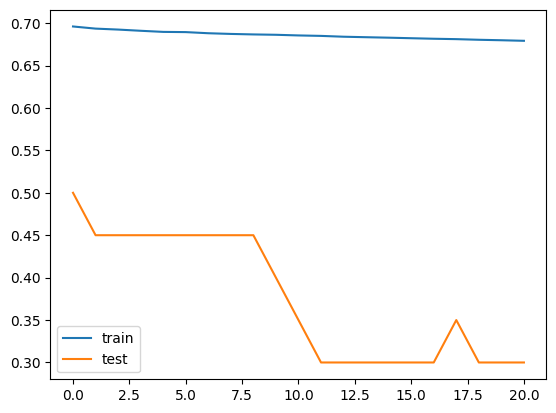

In [41]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


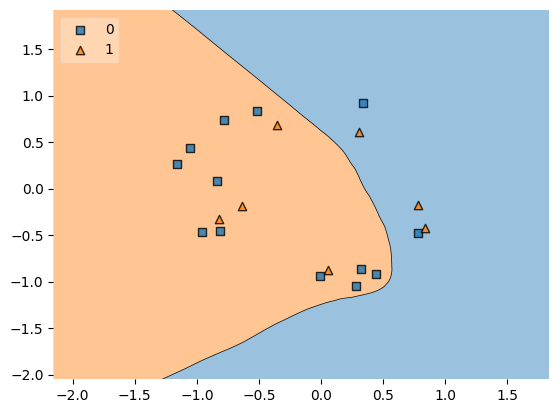

In [42]:
plot_decision_regions(X_test, y_test.ravel(), clf=model, legend=2)
plt.show()